In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import descri_function as des_fun

# read data with model output

In [2]:
# dado com os modelos 
#df = pd.read_parquet("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_27_03_2026_with_MEM_EVI.parquet")
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_03_04_2026_with_MEM_all_mods_ens.parquet')

dta = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/cities_valid_for_MEM_26_03_2026.parquet')


df_ens_and = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/resultado_13-04-2026_mlp_xgb_withConsec.parquet')
df_ens_and = df_ens_and[['co_ibge', 'year_week','prob_ensemble_xgb', 'signal_ensemble_xgb50', 'prob_ensemble_mlp',
       'signal_ensemble_mlp50']]
df_ens_and = df_ens_and.rename(columns={'prob_ensemble_xgb':'prob_ensemble_xgb2', 'signal_ensemble_xgb50': 'signal_ensemble_xgb502', 
                           'prob_ensemble_mlp':'prob_ensemble_mlp2', 'signal_ensemble_mlp50':'signal_ensemble_mlp502'})

df_merged = df.merge(df_ens_and, on=['co_ibge', 'year_week'], how='inner')

df = df_merged.copy()

# Select cities for the manuscript analysis (valid MEM)
lst = list(set(df.co_ibge.unique()) - set(dta.co_ibge.unique()))
df = df[~df.co_ibge.isin(lst)]

df =  df[(df.year_week >= '2022-42') &(df.year_week <= '2025-32')]

# classify MEM surges accordingly to intensity 

In [7]:
df_mem = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/mem_output_26_03_2026.parquet')

df_mem = df_mem[df_mem.epiyear.isin([2022,2023, 2024,2025])]

dta_intens = df_mem.groupby(['co_ibge'])[['baseline', 'post_baseline', 'epidemic_threshold',
       'post_threshold', 'low_level', 'medium_level', 'high_level']].max().reset_index()

In [8]:
# FUNCTION TO ASSIGN INTENSITY

def classify_block(values):
    
    # Check from most severe to least
    if (values > high).any():
        return 'very high'
    
    elif (values > med).any():
        return 'high'
    
    elif (values > low).any():
        return 'medium'
    
    elif (values > epi).any():
        return 'low'
    
    elif ((values > base) & (values <= epi)).any():
        return 'very low'
    
    elif (values <= base).any():
        return 'baseline'
    
    return np.nan


In [9]:
import warnings
warnings.filterwarnings('ignore')

lst = []

for code in df.co_ibge.unique():

    #print(code)

    set_muni = df[df.co_ibge == code].copy()
    set_muni_inten = dta_intens[dta_intens.co_ibge == code]

    thresholds = set_muni_inten.iloc[0]

    base = thresholds['baseline'].astype(int)
    epi = thresholds['epidemic_threshold'].astype(int)
    low = thresholds['low_level'].astype(int)
    med = thresholds['medium_level'].astype(int)
    high = thresholds['high_level'].astype(int)
    very_high = thresholds.get('very_high_level', np.inf)  # fallback if missing


    set_muni = set_muni.sort_values(['year_week'])

    # IDENTIFY BLOCKS

    flag = set_muni['mem_surge_01_correct_with_consec']

    # Create block IDs for consecutive 1s
    set_muni['block'] = (flag != flag.shift()).cumsum()

    # Keep only blocks where flag == 1
    set_muni['intensity'] = np.nan


    #  APPLY TO EACH BLOCK

    for block_id, group in set_muni.groupby('block'):
    
        if group['mem_surge_01_correct_with_consec'].iloc[0] != 1:
            continue
    
        values = group['atend_ivas']
    
        intensity_label = classify_block(values)
    
        set_muni.loc[group.index, 'intensity'] = intensity_label

    lst.append(set_muni)


In [10]:
result = pd.concat(lst)
result['mem_low'] = ((result['intensity'] == 'low') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_medium'] = ((result['intensity'] == 'medium') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_high'] = ((result['intensity'] == 'high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_very_high'] = ((result['intensity'] == 'very high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)

In [11]:
result = result[['co_ibge', 'year_week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'sinal_evi_ivas',
       'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM', 'EWS_COPOD', 'EWS_Rt',
       'prob_ensemble_xgb', 'signal_ensemble_xgb50', 'prob_ensemble_mlp',
       'signal_ensemble_mlp50', 'prob_ensemble_xgb2', 'signal_ensemble_xgb502', 
       'prob_ensemble_mlp2', 'signal_ensemble_mlp502',
        'hard_voting_ivas', 
       'risk_probs', 'sinal_ens_ivas_new', 'block', 'intensity', 'mem_low',
       'mem_medium', 'mem_high', 'mem_very_high']]

# select period

In [12]:
# select period

data = result[result.year_week >= '2025-01']


models = ['sinal_ears_atend',
          'sinal_evi_ivas',
          'EWS_ISF', 
          'EWS_LOF', 
          'EWS_OCSVM', 
          'EWS_COPOD', 
          'EWS_Rt',
          'signal_ensemble_xgb502',
          'signal_ensemble_mlp502',
          'sinal_ens_ivas_new',
          'hard_voting_ivas'
]

warn_col = 'warning_final_mem_surge_01'

warn_col_with_consec = 'mem_surge_01_correct_with_consec'

# See performance all warnings

In [13]:
lst1 = []
lst2 = []

for sel_model in models:

    print(sel_model)

    df_warning_count = des_fun.antici_count(data, sel_model, warn_col,warn_col_with_consec, 'co_ibge')
    
    performance_summary = des_fun.summarize_performance(df_warning_count)

    performance_summary['model'] = sel_model
    df_warning_count['model'] = sel_model

    lst1.append(performance_summary)
    lst2.append(df_warning_count)
        
summary =  pd.concat(lst1)
df_warning_count = pd.concat(lst2)

sinal_ears_atend
sinal_evi_ivas
EWS_ISF
EWS_LOF
EWS_OCSVM
EWS_COPOD
EWS_Rt
signal_ensemble_xgb502
signal_ensemble_mlp502
sinal_ens_ivas_new
hard_voting_ivas


### Plot to see timeliness

In [14]:
df_metrics = summary.copy()

metrics = ['3 weeks earlier', '2 weeks earlier',
       '1 week earlier', 'Same week (0)'
]

df_metrics = df_metrics[df_metrics['Metric'].isin(metrics)]

df_metrics = df_metrics.pivot_table(
    index=['model'],
    columns='Metric',
    values='Value',
    aggfunc="sum"
).reset_index()

cols = ["1 week earlier", "2 weeks earlier", "3 weeks earlier", "Same week (0)"]

df_metrics[cols] = df_metrics[cols].astype(float)

df_metrics.model = df_metrics.model.replace({'EWS_COPOD': 'COPOD', 'EWS_ISF': 'ISF',
                         'EWS_LOF':'LOF', 'EWS_OCSVM': 'OCSVM',
                         'EWS_Rt':'NGM', 'sinal_ears_atend': 'EARS',
                         'sinal_evi_ivas': 'EVI', 'signal_ensemble_xgb502': 'XGBOOST',
                         'signal_ensemble_mlp502':'MLP', 'sinal_ens_ivas_new': 'LR',
                                            'hard_voting_ivas': 'Hard Voting'})

         
        

In [15]:
df_metrics.model.unique()

array(['COPOD', 'ISF', 'LOF', 'OCSVM', 'NGM', 'Hard Voting', 'MLP',
       'XGBOOST', 'EARS', 'LR', 'EVI'], dtype=object)

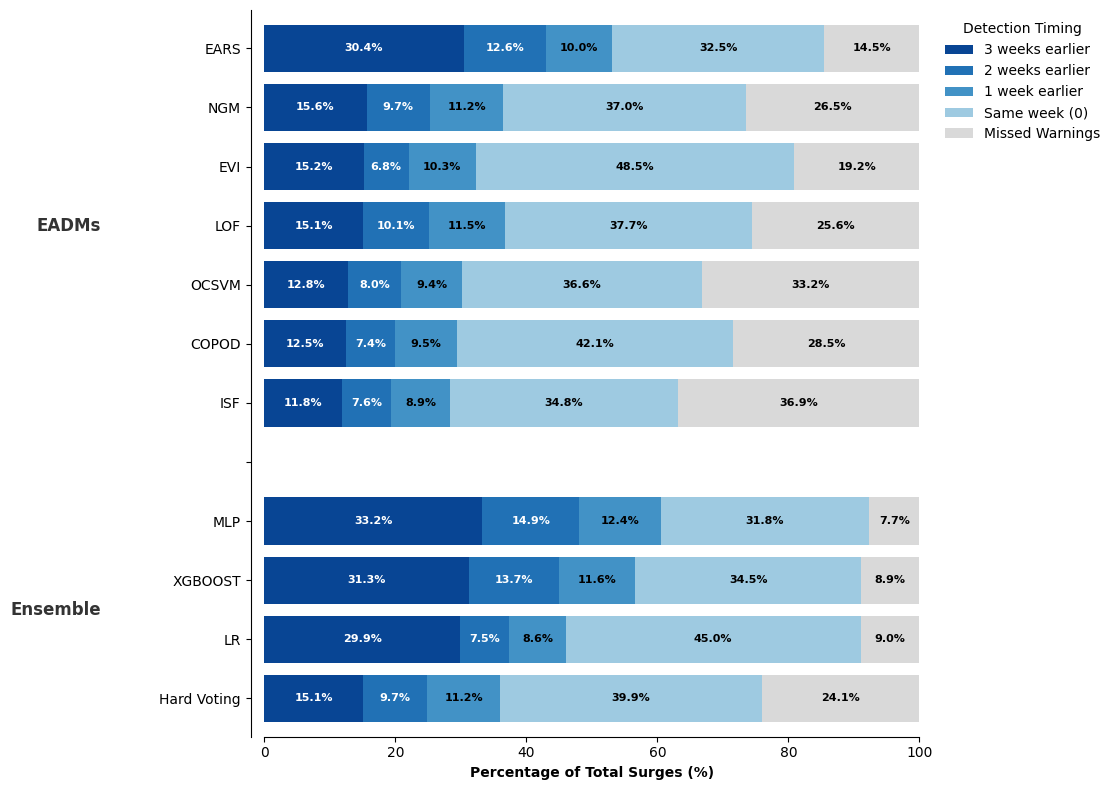

In [16]:
# Calculate Missed Warnings
# Total detection = sum of 0, 1, 2, 3 weeks
df_metrics['Total Detection'] = df_metrics[['3 weeks earlier', '2 weeks earlier', '1 week earlier', 'Same week (0)']].sum(axis=1)
df_metrics['Missed Warnings'] = 100 - df_metrics['Total Detection']

# 1. Preparation & Grouping
ml_ensemble_group = ['XGBOOST', 'LR', 'Hard Voting', 'MLP']

def assign_group(model):
    return 'Ensemble' if model in ml_ensemble_group else 'EADMs'

df_metrics['Group'] = df_metrics['model'].apply(assign_group)

# 2. Sorting and Setting Index
# We sort by Group first, then by '3 weeks earlier' performance
df_sorted = df_metrics.sort_values(by=['Group', '3 weeks earlier'], ascending=[True, False])

# CRITICAL: Set the index to the model names here
df_sorted = df_sorted.set_index('model')

# 3. Create Groups and Inject Spacer
group1 = df_sorted[df_sorted['Group'] == 'EADMs']
group2 = df_sorted[df_sorted['Group'] == 'Ensemble']

# Create a blank spacer row with a single space as the index name
spacer_row = pd.Series(dtype='float64', name=' ') 
df_final = pd.concat([group1, pd.DataFrame([spacer_row]), group2])

# Select only the columns needed for the stacked bar
plot_cols = ['3 weeks earlier', '2 weeks earlier', '1 week earlier', 'Same week (0)', 'Missed Warnings']
df_final_data = df_final[plot_cols]

# 4. Plotting
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

colors = ['#084594', '#2171b5', '#4292c6', '#9ecae1', '#d9d9d9']
fig, ax = plt.subplots(figsize=(12, 8))

# kind='barh' will now use the index (model names) for the y-axis
df_final_data.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.8)

# 5. Formatting
ax.set_xlabel('Percentage of Total Surges (%)', fontweight='bold')
ax.set_xlim(0, 100)
ax.invert_yaxis() # Put the best performing EADMs at the top

# Aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))

# 6. Add Group Labels (to the left of model names)
# We calculate center positions based on row counts
pos1 = (len(group1) - 1) / 2
pos2 = len(group1) + 1 + (len(group2) - 1) / 2

ax.text(-25, pos1, 'EADMs', va='center', ha='right', 
        fontweight='bold', fontsize=12, color='#333333')
ax.text(-25, pos2, 'Ensemble', va='center', ha='right', 
        fontweight='bold', fontsize=12, color='#333333')

# 7. Add Value Labels (skip the spacer)
for n in range(df_final_data.shape[0]):
    model_name = df_final_data.index[n]
    if model_name == ' ': continue # Skip the spacer row
    
    cumulative_width = 0
    for col in plot_cols:
        width = df_final_data.iloc[n][col]
        if width > 4: # Only show if segment is wide enough
            text_color = 'white' if col in ['3 weeks earlier', '2 weeks earlier'] else 'black'
            ax.text(cumulative_width + width/2, n, f'{width:.1f}%', 
                    ha='center', va='center', color=text_color, fontsize=8, fontweight='bold')
        cumulative_width += width

# Legend
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, title='Detection Timing')

plt.tight_layout()
plt.show()

## Plot by performance metrics

In [17]:
df_metrics = summary.copy()

metrics = ['Sensitivity ', 'Specificity', 'PPV', 'NPV']

df_metrics = df_metrics[df_metrics['Metric'].isin(metrics)]

df_metrics["Value"] = (
    df_metrics["Value"]
    .str.replace("%", "", regex=False)  # remove %
    .astype(float) / 100               # convert to proportion (0–1)
)

df_metrics = df_metrics.pivot_table(
    index=['model'],
    columns='Metric',
    values='Value',
    aggfunc="sum"
).reset_index()


df_metrics.model = df_metrics.model.replace({'EWS_COPOD': 'COPOD', 'EWS_ISF': 'ISF',
                         'EWS_LOF':'LOF', 'EWS_OCSVM': 'OCSVM',
                         'EWS_Rt':'NGM', 'sinal_ears_atend': 'EARS',
                         'sinal_evi_ivas': 'EVI',  'signal_ensemble_xgb502': 'XGBOOST',
                         'signal_ensemble_mlp502':'MLP', 'sinal_ens_ivas_new': 'LR',
                                            'hard_voting_ivas': 'Hard Voting'})

In [18]:
df_metrics[['model', 'NPV', 'PPV', 'Sensitivity ', 'Specificity']]

Metric,model,NPV,PPV,Sensitivity,Specificity
0,COPOD,0.985,0.808,0.715,0.912
1,ISF,0.981,0.774,0.631,0.895
2,LOF,0.986,0.756,0.743,0.879
3,OCSVM,0.983,0.765,0.668,0.888
4,NGM,0.986,0.721,0.736,0.855
5,Hard Voting,0.987,0.760,0.759,0.881
6,MLP,0.995,0.658,0.922,0.791
7,XGBOOST,0.995,0.671,0.911,0.804
8,EARS,0.991,0.658,0.855,0.796
9,LR,0.995,0.758,0.910,0.872


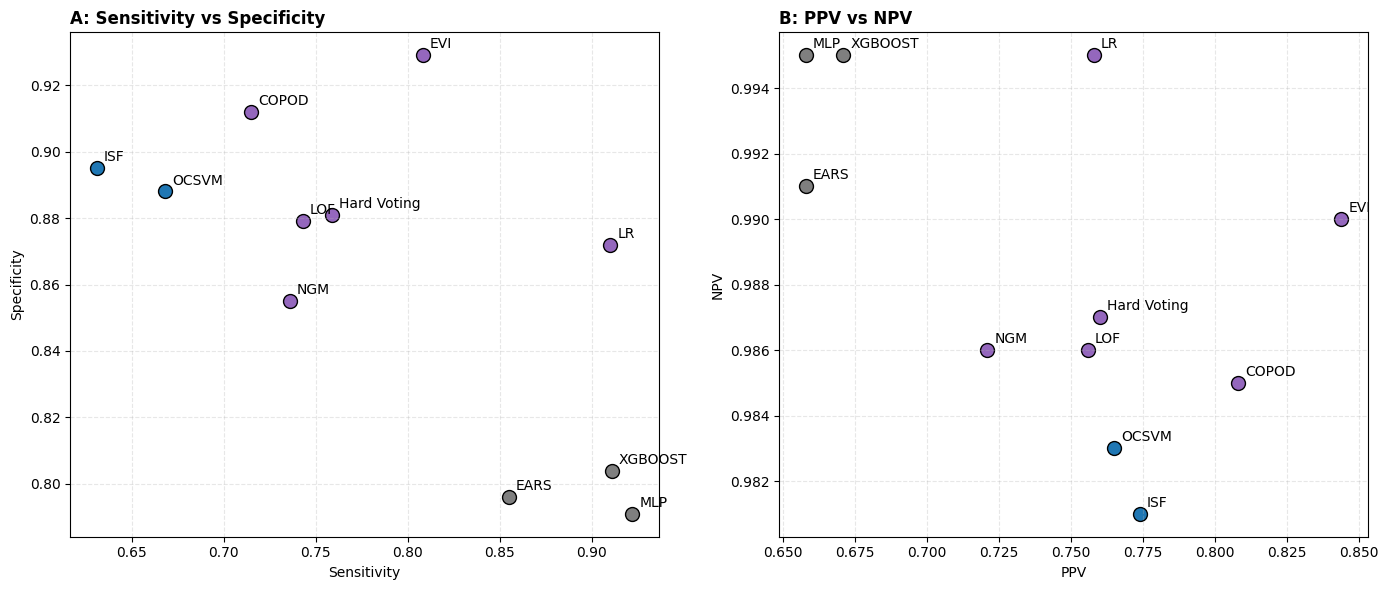

In [21]:


# Analyze distributions to find "better" thresholds
stats = df_metrics.describe()
#print("Stats:\n", stats)

# Proposed Thresholds (Adjusted to provide more variety in categories)
# High Performing: Top tier sensitivity and PPV
# Balanced: Solid sensitivity and PPV
# Aggressive: High sensitivity but lower PPV
# Safe: High NPV and Specificity, but lower Sensitivity
# Conservative: Low Sensitivity, but High Specificity/PPV

se_high = 0.70  # Top quartile
se_mid = 0.50   # Near mean/median
ppv_high = 0.70 # EVI, COPOD
ppv_mid = 0.50  # Median
sp_high = 0.70  # COPOD, EVI
npv_high = 0.70 # EARS, EVI

def categorize_model(row):
    se, ppv, sp, npv = row['Sensitivity '], row['PPV'], row['Specificity'], row['NPV']
    
    # 1. High-performing: Excellent Sensitivity and above-avg PPV
    if se >= 70 and ppv >= 70:
        return 'High-performing'
    
    # 2. Aggressive: High Sensitivity, lower precision
    if se >= 0.70 and ppv < 0.50:
        return 'Aggressive'
        
    # 3. Balanced: Moderate to High Sensitivity and PPV
    if se >= 0.70 and ppv >= 0.70:
        # Check if it fits 'Safe' better
        if sp >= 0.70 and npv >= 0.70:
            return 'Safe/Balanced'
        return 'Balanced'
    
    # 4. Conservative: Prioritizes NPV/Specificity over Sensitivity
    if sp >= 0.70 and se < 0.70:
        return 'Conservative'
    
    return 'Low-performing'

df_metrics['Category'] = df_metrics.apply(categorize_model, axis=1)
#print(df_metrics[['model', 'Category_New']])

# Visualization function for both
def plot_results(df, cat_col, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    colors = {
        'High-performing': '#2ca02c', 
        'Aggressive': '#d62728', 
        'Conservative': '#1f77b4', 
        'Safe/Balanced': '#9467bd', 
        'Balanced': '#ff7f0e', 
        'Low-performing': '#7f7f7f'
    }

    # Plot A: Sensitivity vs PPV
    for cat, color in colors.items():
        sub = df[df[cat_col] == cat]
        if not sub.empty:
            ax1.scatter(sub['Sensitivity '], sub['Specificity'], c=color, label=cat, s=100, edgecolors='k')
            for i, txt in enumerate(sub['model']):
                ax1.annotate(txt, (sub['Sensitivity '].iloc[i], sub['Specificity'].iloc[i]), xytext=(5,5), textcoords='offset points')

    ax1.set_xlabel('Sensitivity'); ax1.set_ylabel('Specificity')
    ax1.set_title('A: Sensitivity vs Specificity', loc='left', fontweight='bold')
    #ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.3)

    # Plot B: Specificity vs NPV
    for cat, color in colors.items():
        sub = df[df[cat_col] == cat]
        if not sub.empty:
            ax2.scatter(sub['PPV'], sub['NPV'], c=color, s=100, edgecolors='k')
            for i, txt in enumerate(sub['model']):
                ax2.annotate(txt, (sub['PPV'].iloc[i], sub['NPV'].iloc[i]), xytext=(5,5), textcoords='offset points')

    ax2.set_xlabel('PPV'); ax2.set_ylabel('NPV')
    ax2.set_title('B: PPV vs NPV', loc='left', fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)

plot_results(df_metrics, 'Category', 'panel_lancet_style_new.png')
#df_metrics.to_csv('model_metrics_categorized.csv', index=False)

# See peformance according intensity

In [38]:
def evaluate_model(df, model_col):

    lst = []

    for col in ['mem_low', 'mem_medium', 'mem_high', 'mem_very_high']:

        df_warning_count = des_fun.antici_count(df, model_col, col, 'co_ibge')
        performance_summary = des_fun.summarize_performance(df_warning_count)

        performance_summary['model'] = model_col
        performance_summary['intensity_level'] = col

        lst.append(performance_summary)
        
    return pd.concat(lst)

In [39]:
# loop over models
all_results = []

for model in models:
    print(f'Running model: {model}')
    res_model = evaluate_model(result, model)
    all_results.append(res_model)

final_summary = pd.concat(all_results)

Running model: sinal_ears_atend


TypeError: antici_count() missing 1 required positional argument: 'col_code'

In [26]:
final_summary['intensity_level'] = final_summary['intensity_level'].str.replace('mem_', '')

In [27]:
order = ['low', 'medium', 'high', 'very_high']
final_summary['intensity_level'] = pd.Categorical(
    final_summary['intensity_level'],
    categories=order,
    ordered=True
)

In [28]:
summary = summary.assign(intensity_level = 'total')

In [29]:
final_summary = pd.concat([final_summary, summary])

In [30]:
final_summary

,Metric,Value,model,intensity_level
0,Total Warnings,8244,EWS_ISF_atend_ivas,low
1,Early Detection (1-3 weeks),1623 (19.7%),EWS_ISF_atend_ivas,low
2,Timely Detection (0 weeks),1201 (14.6%),EWS_ISF_atend_ivas,low
3,Missed Warnings,5420 (65.7%),EWS_ISF_atend_ivas,low
4,Sensitivity,34.3%,EWS_ISF_atend_ivas,low
...,...,...,...,...
5,Specificity,70.0%,sinal_evi_ivas,total
6,PPV,8.6%,sinal_evi_ivas,total
7,POD,85.9%,sinal_evi_ivas,total
8,FPR,30.0%,sinal_evi_ivas,total


# Try a plot

In [40]:
import pandas as pd
import re

df_plot = final_summary.copy()

# Keep only relevant metrics
df_plot = df_plot[df_plot['Metric'].isin([
    'Early Detection (1-3 weeks)',
    'Timely Detection (0 weeks)',
    'Missed Warnings'
])]

# Extract numeric counts
df_plot['count'] = df_plot['Value'].str.extract(r'(\d+)').astype(int)

# Clean metric names
df_plot['detection_type'] = df_plot['Metric'].replace({
    'Early Detection (1-3 weeks)': 'Early',
    'Timely Detection (0 weeks)': 'Timely',
    'Missed Warnings': 'Missed'
})

df_plot['prop'] = df_plot.groupby(
    ['model', 'intensity_level']
)['count'].transform(lambda x: x / x.sum())

order = ['total','low', 'medium', 'high', 'very_high']

df_plot['intensity_level'] = (
    df_plot['intensity_level']
    .str.replace('mem_', '')
)

df_plot['intensity_level'] = pd.Categorical(
    df_plot['intensity_level'],
    categories=order,
    ordered=True
)

df_plot['model'] = (
    df_plot['model']
    .str.replace('EWS_', '')
)

df_plot['model'] = (
    df_plot['model']
    .str.replace('_atend_ivas', '')
)

df_plot['model'] = (
    df_plot['model']
    .str.replace('sinal_evi_ivas', 'EVI')
)

df_plot['model'] = (
    df_plot['model']
    .str.replace('Rt', 'NGM')
)

In [44]:
df_plot.to_csv('antecipacao_models.csv')

In [75]:
#df_plot

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

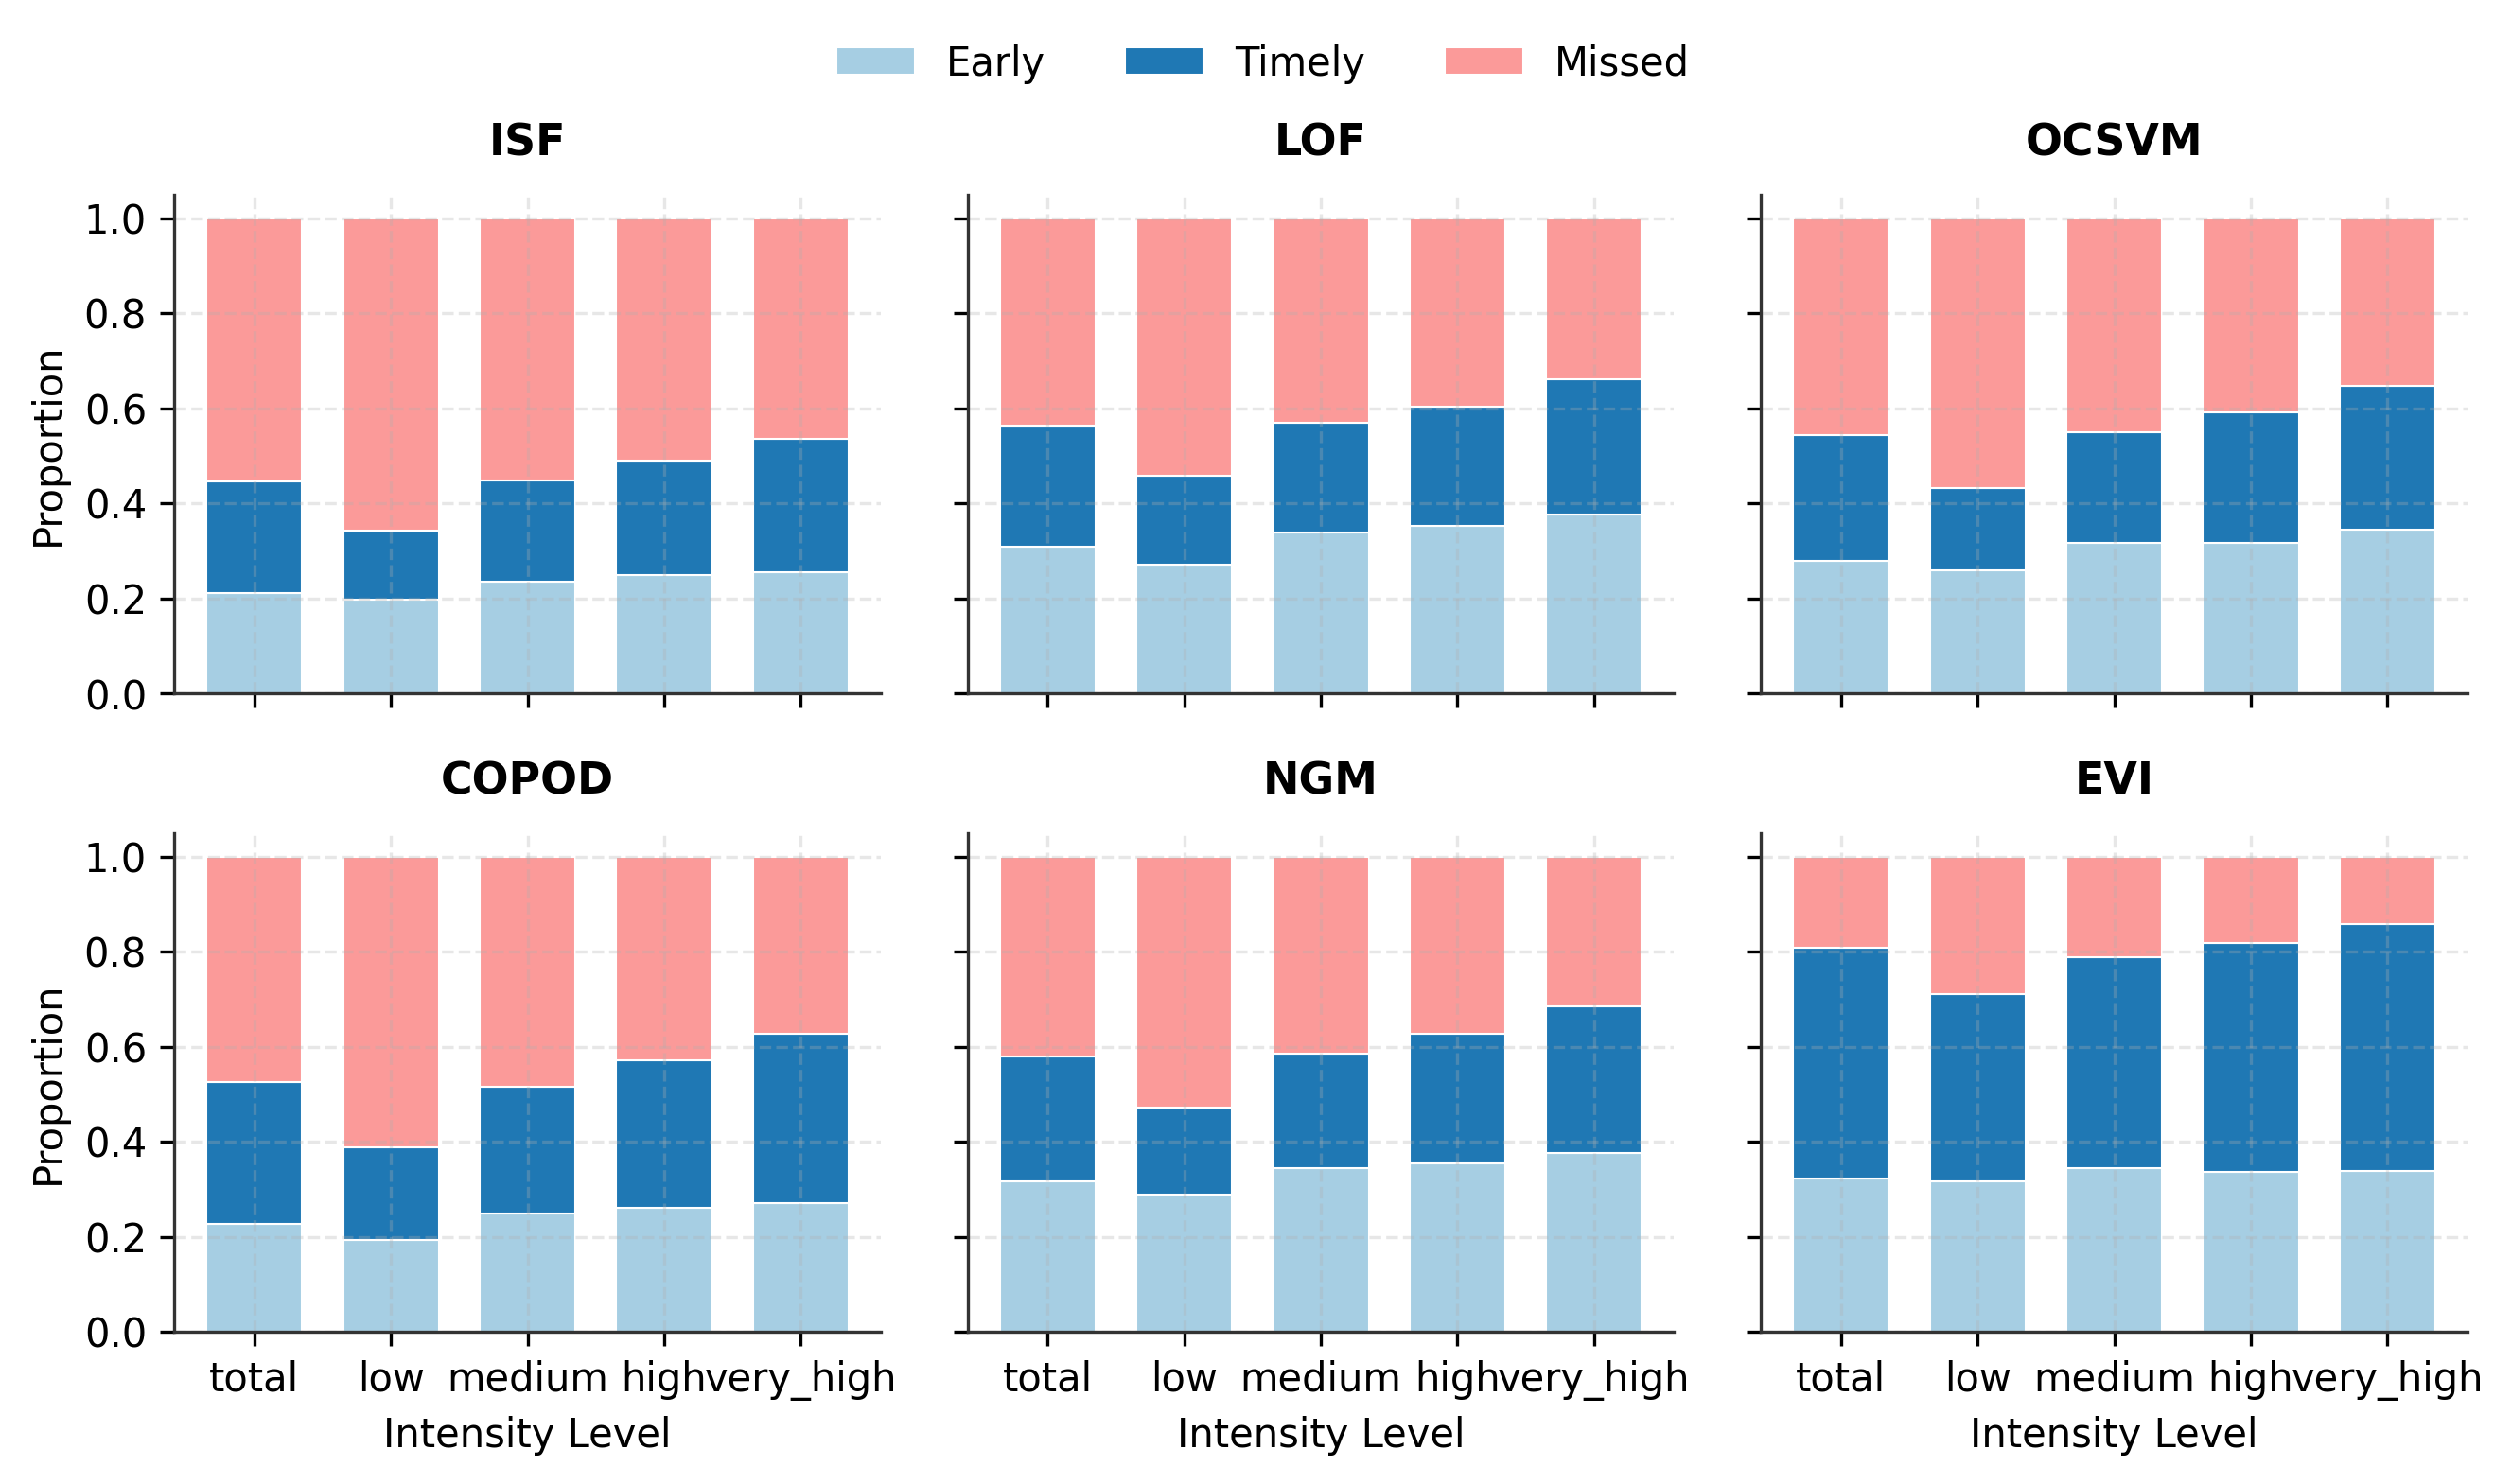

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Configurações de estilo acadêmico
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

# Paleta de cores inspirada em publicações médicas (Lancet/NEJM)
# Timely (Azul escuro), Early (Azul claro), Missed (Coral/Cinza quente)
colors = {
    'Early': '#a6cee3', 
    'Timely': '#1f78b4', 
    'Missed': '#fb9a99'
}

models = df_plot['model'].unique()
n_models = len(models)
nrows = 2
ncols = int(np.ceil(n_models / nrows))

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 5), sharex=True, sharey=True, dpi=300)
axes = axes.flatten()

for i, model in enumerate(models):
    ax = axes[i]
    d = df_plot[df_plot['model'] == model]

    # Pivotagem e ordenação consistente
    pivot = d.pivot(index='intensity_level', columns='detection_type', values='prop').fillna(0)
    categories = ['Early', 'Timely', 'Missed']
    pivot = pivot.reindex(columns=[c for c in categories if c in pivot.columns])

    bottom = np.zeros(len(pivot))

    for col in pivot.columns:
        ax.bar(
            pivot.index.astype(str), # Garante que o X seja categórico
            pivot[col],
            bottom=bottom,
            label=col,
            color=colors.get(col, '#333333'),
            width=0.7,
            edgecolor='white',
            linewidth=0.5
        )
        bottom += pivot[col].values

    # Estética do Subplot
    ax.set_title(f"{model}", fontsize=11, fontweight='bold', pad=10)
    ax.set_ylim(0, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Rótulos apenas nas bordas externas para evitar repetição
    if i % ncols == 0:
        ax.set_ylabel('Proportion', fontsize=10)
    
    if i >= (n_models - ncols):
        ax.set_xlabel('Intensity Level', fontsize=10)

# Remover eixos de plots vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajuste da Legenda (Horizontal no topo)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=3, frameon=False, fontsize=10)

plt.tight_layout()

# Dica: Salve em PDF ou TIFF para a submissão
plt.savefig("/home/juliane.oliveira/workspace/aesop-detection-models/figures/detection_plot.pdf", bbox_inches='tight')
plt.show()